# Pitcher Similarity Collaborative Filtering

### Alexander Tu, Dhillon Murphy, Dylan Weinmann

All data from Baseball Savant (https://baseballsavant.mlb.com/)

In [56]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [57]:
raw_pitcher_data_2025 = pd.read_csv('data/2025_stats.csv')
raw_pitcher_data_2025.rename(columns={'last_name, first_name': 'name'}, inplace=True)
raw_pitcher_data_2025.columns = [c.split('_')[1] if c.startswith('n_') and c.endswith('_formatted') else c for c in raw_pitcher_data_2025.columns]
raw_pitcher_data_2025.head()

,name,player_id,year,ff,sl,ch,cu,si,fc,fs,kn,st,sv,fo
0,"Cantillo, Joey",676282,2025,42.0,8.7,30.5,18.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Harris, Hogan",663687,2025,56.7,1.6,13.2,22.8,NaN,2.7,NaN,NaN,3.1,NaN,NaN
2,"Okert, Steven",595345,2025,41.2,57.8,0.1,NaN,NaN,0.9,NaN,NaN,NaN,NaN,NaN
3,"Díaz, Edwin",621242,2025,52.6,47.3,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Irvin, Jake",663623,2025,32.0,4.3,7.7,29.6,22.2,4.2,NaN,NaN,NaN,NaN,NaN


In [58]:
raw_pitcher_data_2026 = pd.read_csv('data/2026_stats.csv')
raw_pitcher_data_2026.rename(columns={'last_name, first_name': 'name'}, inplace=True)
raw_pitcher_data_2026.columns = [c.split('_')[1] if c.startswith('n_') and c.endswith('_formatted') else c for c in raw_pitcher_data_2026.columns]
raw_pitcher_data_2026.head()

,name,player_id,year,ff,sl,ch,cu,si,fc,fs,kn,st,sv,fo
0,"Vásquez, Randy",681190,2026,33.5,4.5,12.0,9.4,12.0,20.7,NaN,NaN,7.9,NaN,NaN
1,"Woodruff, Brandon",605540,2026,40.7,NaN,20.3,4.8,20.8,11.3,NaN,NaN,2.2,NaN,NaN
2,"Williams, Devin",642207,2026,54.7,NaN,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Headrick, Brent",687396,2026,42.9,36.1,NaN,NaN,16.5,NaN,4.5,NaN,NaN,NaN,NaN
4,"Latz, Jacob",656641,2026,49.4,28.8,11.2,10.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
common = set(raw_pitcher_data_2025['player_id']) & set(raw_pitcher_data_2026['player_id'])
raw_pitcher_data_2025 = raw_pitcher_data_2025[raw_pitcher_data_2025['player_id'].isin(common)]
raw_pitcher_data_2026 = raw_pitcher_data_2026[raw_pitcher_data_2026['player_id'].isin(common)]

All curveballs are condensed into one 'Curveball' and Forkballs are classified as 'Splitter' due to similar function and lack of Forkball data

In [60]:
pt_dict = {'ff': '4-Seamer',
           'sl': 'Slider',
           'ch': 'Changeup',
           'si': 'Sinker',
           'fc': 'Cutter',
           'st': 'Sweeper',
           }

In [61]:
pitchers_2025 = raw_pitcher_data_2025[['name', 'player_id']].reset_index(drop=True)

pitch_percentages_2025 = (
    raw_pitcher_data_2025[['ff', 'sl', 'ch', 'cu', 'si', 'fc', 'fs', 'kn', 'st', 'sv', 'fo']]
    .copy()
    .fillna(0)
    .assign(
        Curveball=lambda d: d['cu'] + d['kn'] + d['sv'],
        Splitter=lambda d: d['fs'] + d['fo']
    )
    .drop(columns=['cu', 'kn', 'sv', 'fs', 'fo'])
    .rename(columns=pt_dict)
    .reset_index(drop=True)
)
pitch_percentages_2025.head()

,4-Seamer,Slider,Changeup,Sinker,Cutter,Sweeper,Curveball,Splitter
0,42.0,8.7,30.5,0.0,0.0,0.0,18.8,0.0
1,56.7,1.6,13.2,0.0,2.7,3.1,22.8,0.0
2,41.2,57.8,0.1,0.0,0.9,0.0,0.0,0.0
3,52.6,47.3,0.1,0.0,0.0,0.0,0.0,0.0
4,32.0,4.3,7.7,22.2,4.2,0.0,29.6,0.0


In [62]:
pitchers_2026 = raw_pitcher_data_2026[['name', 'player_id']].reset_index(drop=True)

pitch_percentages_2026 = (
    raw_pitcher_data_2026[['ff', 'sl', 'ch', 'cu', 'si', 'fc', 'fs', 'kn', 'st', 'sv', 'fo']]
    .copy()
    .fillna(0)
    .assign(
        Curveball=lambda d: d['cu'] + d['kn'] + d['sv'],
        Splitter=lambda d: d['fs'] + d['fo']
    )
    .drop(columns=['cu', 'kn', 'sv', 'fs', 'fo'])
    .rename(columns=pt_dict)
    .reset_index(drop=True)
)
pitch_percentages_2026.head()

,4-Seamer,Slider,Changeup,Sinker,Cutter,Sweeper,Curveball,Splitter
0,33.5,4.5,12.0,12.0,20.7,7.9,9.4,0.0
1,40.7,0.0,20.3,20.8,11.3,2.2,4.8,0.0
2,54.7,0.0,45.3,0.0,0.0,0.0,0.0,0.0
3,49.4,28.8,11.2,0.0,0.0,0.0,10.6,0.0
4,46.0,0.4,0.0,2.9,0.0,12.4,2.9,35.4


In [63]:
# Uses Centered Log Ratio on the items due to them being raw percentages
# No additional scaling because CLR is a form of scaling already
def clr(x):
    x = x + 0.001
    log_x = np.log(x)
    return log_x - log_x.mean(axis=1, keepdims=True)

In [64]:
pitcher_clr = clr(pitch_percentages_2025.values)

# Uses L2 norm to compute similarity
dist_matrix = cdist(pitcher_clr, pitcher_clr, metric='euclidean')
sim_matrix = 1 / (1 + dist_matrix)

In [65]:
def pitch_change_recommend(name, k=5, print_similar=False):
    i = pitchers_2025[pitchers_2025['name'] == name].index[0]
    scores = sim_matrix[i]
    top_k = np.argsort(scores)[::-1][1:k+1]
    most_similar = pd.DataFrame(columns=['name', 'player_id', 'score'])

    if print_similar:
        print(f'Pitcher: {pitchers_2025.iloc[i]["name"]}')
        print(pitch_percentages_2025.iloc[i].to_string())
        print('\n-------\n')

    for num, j in enumerate(top_k):
        most_similar.loc[num] = [pitchers_2025.iloc[j]['name'], pitchers_2025.iloc[j]['player_id'], scores[j]]
        if print_similar:
            print(f'#{num + 1} most similar pitcher: {pitchers_2025.iloc[j]["name"]}')
            print(pitch_percentages_2025.iloc[j].to_string())
            print()

    total_score = most_similar['score'].sum()
    pitcher_name = pitchers_2025.iloc[i]['name']
    print(f'{pitcher_name}:')

    recommendations = {}
    current_pcts = {}
    for pitch in pitch_percentages_2025.columns:
        rec = 0.0
        for _, sim in most_similar.iterrows():
            index_2025 = pitchers_2025.index[pitchers_2025['player_id'] == sim['player_id']]
            index_2026 = pitchers_2026.index[pitchers_2026['player_id'] == sim['player_id']]
            per_2025 = pitch_percentages_2025[pitch].iloc[index_2025].values[0]
            per_2026 = pitch_percentages_2026[pitch].iloc[index_2026].values[0]
            rec += (per_2026 - per_2025) * sim['score']
        rec = round(rec / total_score, 2)
        recommendations[pitch] = rec
        current_pcts[pitch] = round(pitch_percentages_2025[pitch].iloc[i], 1)
        print(f'{pitch}: {rec}')

    pitches = list(recommendations.keys())
    current = [current_pcts[p] for p in pitches]
    changes = [recommendations[p] for p in pitches]

    fig, ax = plt.subplots(figsize=(8, len(pitches) * 0.7 + 1.5))

    for idx, (pitch, cur, chg) in enumerate(zip(pitches, current, changes)):
        ax.barh(idx, cur, color='steelblue', height=0.5, label='2025 %' if idx == 0 else '')

        if chg >= 0:
            ax.barh(idx, chg, left=cur, color='limegreen', height=0.5, label='Increase' if idx == 0 else '')
        else:
            ax.barh(idx, abs(chg), left=cur + chg, color='tomato', height=0.5, label='Decrease' if idx == 0 else '')

    ax.set_yticks(range(len(pitches)))
    ax.set_yticklabels(pitches)
    ax.invert_yaxis()
    ax.set_xlabel('Usage (%)')
    ax.set_title(f'Recommended Pitch Mix Changes — {pitcher_name}', fontsize=13, pad=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, max(c + max(chg, 0) for c, chg in zip(current, changes)) + 8)
    plt.tight_layout()
    plt.show()

Baz, Shane:
4-Seamer: -0.53
Slider: 0.14
Changeup: 0.97
Sinker: 1.27
Cutter: -0.44
Sweeper: 0.33
Curveball: -2.03
Splitter: 0.29


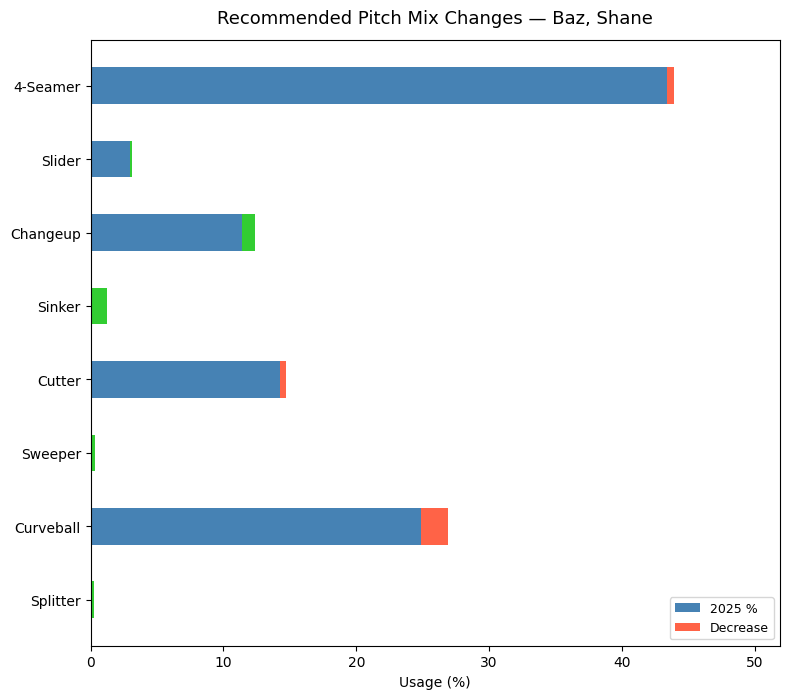

In [ ]:
shane_baz_similar = pitch_change_recommend('Baz, Shane')